# Pre-Producción

Objetivo: validar el pipeline completo de inferencia sobre el **dataset de validación** (nunca visto durante el desarrollo). Este notebook constituye la evaluación final e independiente del modelo seleccionado.

Modelo seleccionado: **XGBoost — Experimento B, umbral = 0.078**  
Artefacto: `03_Modelos/xgb_pha_B_v1_pipeline.joblib`  
Dataset de validación: `01_Datos/02_Validacion/validacion.csv`

## 1. Importar paquetes

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score,
    precision_recall_curve, f1_score, classification_report
)
warnings.filterwarnings('ignore')

## 2. Rutas y carga de artefactos

Se resuelve la raíz del repositorio y se cargan todos los artefactos generados durante el desarrollo:
- Modelo seleccionado (`xgb_pha_B_v1_pipeline.joblib`)
- Encoder y scaler entrenados en preprocesamiento
- JSON de selección con el umbral óptimo

In [2]:
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'README.md').exists():
    repo_root = repo_root.parent

if not (repo_root / 'README.md').exists():
    raise FileNotFoundError('No se encontró la raíz del repositorio (README.md).')

datos_dir      = repo_root / '01_Datos'
modelos_dir    = repo_root / '03_Modelos'
resultados_dir = repo_root / '04_Resultados'
resultados_dir.mkdir(parents=True, exist_ok=True)

print(f'Raíz del repositorio : {repo_root}')
print(f'Datos                : {datos_dir}')
print(f'Modelos              : {modelos_dir}')

Raíz del repositorio : C:\Users\matia\GitHub\Asteroid_Classification
Datos                : C:\Users\matia\GitHub\Asteroid_Classification\01_Datos
Modelos              : C:\Users\matia\GitHub\Asteroid_Classification\03_Modelos


In [3]:
# Cargar selección del modelo final
with open(resultados_dir / 'seleccion_modelo_final.json', encoding='utf-8') as f:
    seleccion = json.load(f)

umbral_opt    = seleccion['umbral']
nombre_modelo = seleccion['modelo']

print(f'Modelo seleccionado : {nombre_modelo}')
print(f'Umbral óptimo       : {umbral_opt}')
print(f'Recall CV (trabajo) : {seleccion["metricas_umbral_opt"]["recall"]}')
print(f'FN en trabajo       : {seleccion["metricas_umbral_opt"]["fn"]}')

Modelo seleccionado : xgb_pha_B_v1_pipeline.joblib
Umbral óptimo       : 0.077681
Recall CV (trabajo) : 0.8785
FN en trabajo       : 13


In [4]:
# Cargar modelo, encoder y scaler
modelo     = joblib.load(modelos_dir / nombre_modelo)
encoder    = joblib.load(modelos_dir / 'pipeline_encoder.joblib')
scaler     = joblib.load(modelos_dir / 'pipeline_scaler.joblib')

print(f'Modelo  : {type(modelo).__name__}')
print(f'Encoder : {type(encoder).__name__}')
print(f'Scaler  : {type(scaler).__name__}')

Modelo  : XGBClassifier
Encoder : TargetEncoder
Scaler  : RobustScaler


## 3. Carga del dataset de validación

`validacion.csv` es el conjunto reservado desde la etapa de Setup (notebook 01). No fue visto en ninguna etapa de desarrollo, entrenamiento ni análisis.

In [5]:
df_val = pd.read_csv(datos_dir / '02_Validacion' / 'validacion.csv')

print(f'Dataset de validación : {df_val.shape}')
print(f'PHAs en validación    : {(df_val["pha"] == "Y").sum()} ({(df_val["pha"] == "Y").mean()*100:.2f}%)')
df_val.head(3)

Dataset de validación : (37839, 36)
PHAs en validación    : 49 (0.13%)


,Unnamed: 0,spkid,full_name,pha,H,diameter,albedo,diameter_sigma,e,a,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,48862,2078686,' 78686 (2002 TA139)',N,15.1,2.137,0.322,0.617,0.106515,2.516573,...,0.000005,0.000032,0.000047,0.000040,1.653400e-08,2.198800e-09,0.000161,0.000013,MBA,0.52783
1,890,2000897,' 897 Lysistrata (1918 DZ)',N,10.3,24.337,0.214,0.27699999999999997,0.094531,2.540918,...,0.000005,0.000017,0.000028,0.000022,9.470500e-09,1.243000e-09,0.000090,0.000008,MBA,0.40465
2,74435,2152809,'152809 (1999 TU197)',N,14.5,7.065,0.074,0.308,0.133419,2.972882,...,0.000005,0.000029,0.000039,0.000024,3.382000e-08,2.894900e-09,0.000125,0.000028,MBA,0.47891


## 4. Preprocesamiento del dataset de validación

Se replica exactamente el pipeline del notebook 04, aplicando los transformadores guardados con `.transform()` — nunca `.fit()`.

**Orden obligatorio** (determinado por cómo se entrenaron los artefactos):
1. Eliminar identificadores (`Unnamed: 0`, `spkid`, `full_name`)
2. Codificar `pha` → binario
3. `TargetEncoder.transform()` sobre `class`
4. Reordenar a las 32 columnas que espera el `RobustScaler` (orden fijo)
5. `RobustScaler.transform()`
6. Eliminar columnas redundantes post-escalado (`ad`, `n`, `per`, `per_y`, `moid`, `moid_ld`)

In [6]:
COLS_IDS        = ['Unnamed: 0', 'spkid', 'full_name']
COLS_POST_SCALE = ['ad', 'n', 'per', 'per_y', 'moid', 'moid_ld']
SCALER_COLS     = list(scaler.feature_names_in_)   # 32 columnas, orden fijo

# Medianas de entrenamiento para imputar valores faltantes (extraídas del scaler)
medianas_entrenamiento = dict(zip(SCALER_COLS, scaler.center_))

# 1. Eliminar identificadores
df_proc = df_val.drop(columns=[c for c in COLS_IDS if c in df_val.columns])

# 2. Codificar target
y_val = (df_proc.pop('pha') == 'Y').astype(int)
X_val = df_proc.copy()

# 3. Reemplazar '?' por NaN e imputar con mediana de entrenamiento
X_val.replace('?', np.nan, inplace=True)
for col in SCALER_COLS:
    if col in X_val.columns and X_val[col].isna().any():
        n_imp = X_val[col].isna().sum()
        X_val[col] = X_val[col].astype(float).fillna(medianas_entrenamiento[col])
        print(f'  Imputados {n_imp} NaN en {col!r} con mediana={medianas_entrenamiento[col]:.4f}')

# 4. TargetEncoder sobre 'class' (.transform — nunca .fit)
X_val[['class']] = encoder.transform(X_val[['class']])

# 5. Reordenar columnas al orden exacto que espera el scaler
X_val_ordered = X_val[SCALER_COLS].astype(float)

# 6. RobustScaler (.transform — nunca .fit)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_ordered),
    columns=SCALER_COLS
)

# 7. Eliminar columnas redundantes post-escalado
X_val_final = X_val_scaled.drop(columns=COLS_POST_SCALE)

print(f'y_val shape      : {y_val.shape}  — PHAs: {y_val.sum()}')
print(f'X_val_final shape: {X_val_final.shape}')
print(f'Columnas         : {X_val_final.columns.tolist()}')

  Imputados 30 NaN en 'diameter_sigma' con mediana=0.3210
y_val shape      : (37839,)  — PHAs: 49
X_val_final shape: (37839, 26)
Columnas         : ['H', 'diameter', 'albedo', 'diameter_sigma', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'tp', 'tp_cal', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']


In [7]:
# Verificar alineación con el modelo: las columnas deben coincidir exactamente
features_modelo = list(modelo.feature_names_in_) if hasattr(modelo, 'feature_names_in_') else None

if features_modelo:
    diff = set(X_val_final.columns) - set(features_modelo)
    missing = set(features_modelo) - set(X_val_final.columns)
    print(f'Features del modelo : {len(features_modelo)}')
    print(f'Features de X_val   : {len(X_val_final.columns)}')
    print(f'Extra en X_val      : {diff if diff else "ninguna"}')
    print(f'Faltantes en X_val  : {missing if missing else "ninguna"}')
    if not diff and not missing:
        print('Alineación correcta — listo para predicción.')
else:
    print(f'X_val_final: {X_val_final.shape} — sin validación de nombres de features disponible.')

Features del modelo : 26
Features de X_val   : 26
Extra en X_val      : ninguna
Faltantes en X_val  : ninguna
Alineación correcta — listo para predicción.


## 5. Predicciones sobre validación

Se aplica el umbral óptimo (0.078) determinado en la etapa de análisis mediante optimización por F2-score.

In [8]:
y_proba_val = modelo.predict_proba(X_val_final)[:, 1]
y_pred_val  = (y_proba_val >= umbral_opt).astype(int)

total_pha = int(y_val.sum())
tp = int(((y_val == 1) & (y_pred_val == 1)).sum())
fn = int(((y_val == 1) & (y_pred_val == 0)).sum())
fp = int(((y_val == 0) & (y_pred_val == 1)).sum())
tn = int(((y_val == 0) & (y_pred_val == 0)).sum())

print(f'PHAs totales en validación : {total_pha}')
print(f'  TP (detectados)          : {tp}  ({tp/total_pha*100:.1f}%)')
print(f'  FN (no detectados)       : {fn}  ({fn/total_pha*100:.1f}%) ← crítico')
print(f'  FP (falsas alarmas)      : {fp}')
print(f'  TN                       : {tn}')

PHAs totales en validación : 49
  TP (detectados)          : 43  (87.8%)
  FN (no detectados)       : 6  (12.2%) ← crítico
  FP (falsas alarmas)      : 56
  TN                       : 37734


## 6. Evaluación final

Métricas finales sobre el dataset de validación. Estas cifras son las únicas que reflejan rendimiento genuino sobre datos completamente no vistos.

In [9]:
recall_val    = tp / (tp + fn)
precision_val = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
f1_val        = f1_score(y_val, y_pred_val)
auc_val       = roc_auc_score(y_val, y_proba_val)
ap_val        = average_precision_score(y_val, y_proba_val)

print('=== Métricas finales — Dataset de validación ===')
print(f'  AUC-ROC          : {auc_val:.4f}')
print(f'  Avg Precision    : {ap_val:.4f}')
print(f'  Recall (PHA)     : {recall_val:.4f}')
print(f'  Precisión (PHA)  : {precision_val:.4f}')
print(f'  F1               : {f1_val:.4f}')
print(f'  FN               : {fn} ({fn/total_pha*100:.1f}%)')
print()
print('=== Comparación trabajo vs. validación ===')
print(f'  Recall trabajo   : {seleccion["metricas_umbral_opt"]["recall"]}  →  Validación: {recall_val:.4f}')
print(f'  FN trabajo       : {seleccion["metricas_umbral_opt"]["fn"]}          →  Validación: {fn}')

=== Métricas finales — Dataset de validación ===
  AUC-ROC          : 0.9994
  Avg Precision    : 0.5814
  Recall (PHA)     : 0.8776
  Precisión (PHA)  : 0.4343
  F1               : 0.5811
  FN               : 6 (12.2%)

=== Comparación trabajo vs. validación ===
  Recall trabajo   : 0.8785  →  Validación: 0.8776
  FN trabajo       : 13          →  Validación: 6


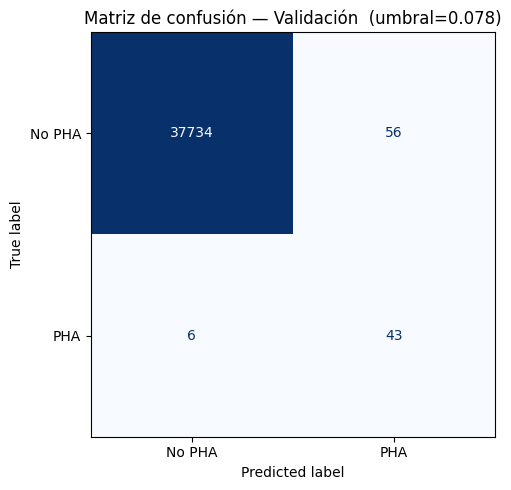

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No PHA', 'PHA'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión — Validación  (umbral={umbral_opt:.3f})')
plt.tight_layout()
plt.savefig(resultados_dir / 'confusion_matrix_validacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Guardar métricas finales
metricas_finales = {
    'dataset':    'validacion',
    'modelo':     nombre_modelo,
    'umbral':     umbral_opt,
    'n_total':    len(y_val),
    'n_pha':      total_pha,
    'auc_roc':    round(auc_val, 4),
    'avg_precision': round(ap_val, 4),
    'recall':     round(recall_val, 4),
    'precision':  round(precision_val, 4),
    'f1':         round(f1_val, 4),
    'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
}

with open(resultados_dir / 'metricas_validacion.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_finales, f, ensure_ascii=False, indent=2)

print('Métricas guardadas en 04_Resultados/01_Analisis/02_Preproduccion/metricas_validacion.json')
print(json.dumps(metricas_finales, indent=2))

Métricas guardadas en 04_Resultados/01_Analisis/02_Preproduccion/metricas_validacion.json
{
  "dataset": "validacion",
  "modelo": "xgb_pha_B_v1_pipeline.joblib",
  "umbral": 0.077681,
  "n_total": 37839,
  "n_pha": 49,
  "auc_roc": 0.9994,
  "avg_precision": 0.5814,
  "recall": 0.8776,
  "precision": 0.4343,
  "f1": 0.5811,
  "tp": 43,
  "fn": 6,
  "fp": 56,
  "tn": 37734
}
